# LendingClub Final Research Notebook

This notebook is a thin final-report layer over saved experiment and analysis artifacts. It does not rerun the experiment matrix, retrain models, or implement CLIP-style validation.

## 1. Setup and Imports

In [1]:
from IPython.display import Markdown, display

from credit_risk_fs.reporting.notebook_report import (
    load_dataset_report_inputs,
    load_dataset_snapshot,
    load_split_summary,
    load_time_bucket_summary,
    load_final_comparison,
    load_stability_table,
    load_drift_table,
    load_semantic_coverage_table,
    load_best_runs,
    load_run_artifacts,
    plot_dev_oot_split_diagnostics,
    plot_observation_count_by_time,
    plot_bad_rate_by_time,
    plot_metric_leaderboard,
    plot_stability_vs_performance,
    plot_drift_vs_performance,
    plot_semantic_coverage,
    plot_runtime_tradeoff,
    summarize_split_rationale,
    summarize_dataset_findings,
    summarize_clip_validation_placeholder,
    load_feature_level_psi_by_run,
    load_psi_distribution_by_pipeline,
    load_high_psi_features_by_pipeline,
    load_llm_then_mrmr_drift_source_breakdown,
    load_semantic_redundancy_table,
    load_paired_fold_significance_tests,
    load_governance_note,
    load_llm_top100_candidate_psi,
    lendingclub_monthly_bad_rate_observation_count_table,
    plot_lendingclub_monthly_bad_rate_observation_count,
    save_final_report_plots,
)


## 2. Load Prepared Report Inputs

In [2]:
dataset_name = 'lendingclub'

inputs = load_dataset_report_inputs(dataset_name)
snapshot = load_dataset_snapshot(dataset_name)
split_summary = load_split_summary(dataset_name)
time_buckets = load_time_bucket_summary(dataset_name)
final_comparison = load_final_comparison(dataset_name)
stability = load_stability_table(dataset_name)
drift = load_drift_table(dataset_name)
semantic_coverage = load_semantic_coverage_table(dataset_name)
best_runs = load_best_runs(dataset_name)
feature_level_psi = load_feature_level_psi_by_run(dataset_name)
psi_distribution = load_psi_distribution_by_pipeline(dataset_name)
high_psi_features = load_high_psi_features_by_pipeline(dataset_name)
llm_then_mrmr_drift = load_llm_then_mrmr_drift_source_breakdown(dataset_name)
llm_top100_candidate_psi = load_llm_top100_candidate_psi(dataset_name)
semantic_redundancy = load_semantic_redundancy_table(dataset_name)
paired_significance = load_paired_fold_significance_tests(dataset_name)
governance_note = load_governance_note(dataset_name)
findings = summarize_dataset_findings(dataset_name)
clip_placeholder = summarize_clip_validation_placeholder(dataset_name)
plot_manifest = save_final_report_plots(dataset_name)

run_artifacts = load_run_artifacts(dataset_name, best_runs.iloc[0]["run_id"]) if not best_runs.empty and "run_id" in best_runs.columns else {}


## 3. Research Question and Dataset Role

The research question is whether LLM-based metadata screening is useful as a first-stage feature-selection helper for credit-risk modeling under a time-based DEV/OOT validation protocol. Logistic Regression and CatBoost are evaluation vehicles; the claim is about feature screening, not deployment modeling.

In [3]:
display(Markdown(findings['experiment_matrix_markdown']))

The matrix compares statistical baselines, pure LLM screening, and LLM-then-statistical hybrids under the same DEV/OOT protocol. The target comparison is therefore about first-stage screening utility, not about replacing the downstream LR or CatBoost evaluation vehicles.

## 4. Dataset Snapshot

In [4]:
display(snapshot)

,dataset_name,dataset_role,DEV_rows,OOT_rows,DEV_bad_rate,OOT_bad_rate,time_column,DEV_window,OOT_window,engineered_candidate_features,encoded_or_modeling_features_if_available,LR_feature_budget,CatBoost_feature_budget,completed_runs,failed_runs
0,LendingClub,external validation,598649,293105,0.1954,0.2329,recent_decision,"[-1795, -1065)","[-1065, -730]",300.0,96.0,20.0,40.0,16,0


## 5. DEV/OOT Split Rationale

In [5]:
display(Markdown(summarize_split_rationale(dataset_name)))
display(split_summary)

The split is time-based rather than random. DEV is the older window used for cross-validation, feature selection, and model fitting, while OOT is the newer holdout used only for final evaluation. The window choice is justified by observation counts and target-rate behavior across time, with the goal of keeping both periods large enough for comparison without leaking future information into selector or model tuning. OOT bad rate is reported only to justify the validation setup; it is not used to tune feature selection or hyperparameters. For LendingClub, the configured relative window uses DEV from -1795 inclusive to -1065 exclusive and OOT from -1065 inclusive to -730 inclusive on `recent_decision`, which is derived from issue date to simulate future-loan validation. On the processed LendingClub application table, the DEV window corresponds approximately to issue dates 2014-01-01 through 2015-12-01, and OOT corresponds to 2016-01-01 through 2016-12-01. This produces 598,649 DEV rows and 293,105 OOT rows, with bad rates of 0.1954 and 0.2329; the difference is 0.0375. OOT has a higher bad rate than DEV, which makes LendingClub a harder external validation period, while both DEV and OOT retain enough observations for a meaningful comparison.

,dataset,dataset_display_name,time_column,DEV_start,DEV_end,OOT_start,OOT_end,DEV_window,OOT_window,DEV_rows,...,OOT_bad_rate,bad_rate_difference,OOT_DEV_row_ratio,dropped_older_rows,dropped_missing_time_rows,source_row_count,DEV_issue_date_start,DEV_issue_date_end,OOT_issue_date_start,OOT_issue_date_end
0,lendingclub,LendingClub,recent_decision,-1795,-1065,-1065,-730,"[-1795, -1065)","[-1065, -730]",598649,...,0.2329,0.0375,0.4896,230706,0,1348099,2014-01-01,2015-12-01,2016-01-01,2016-12-01


## 6. DEV/OOT Split Diagnostics

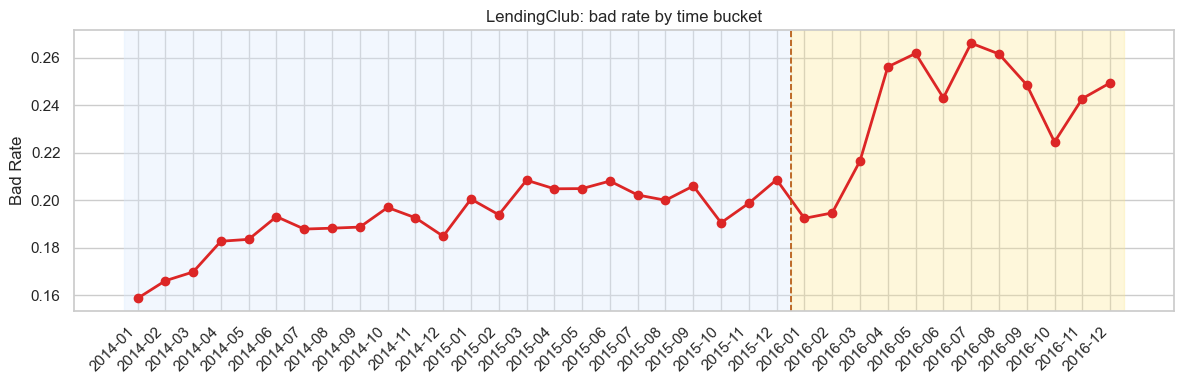

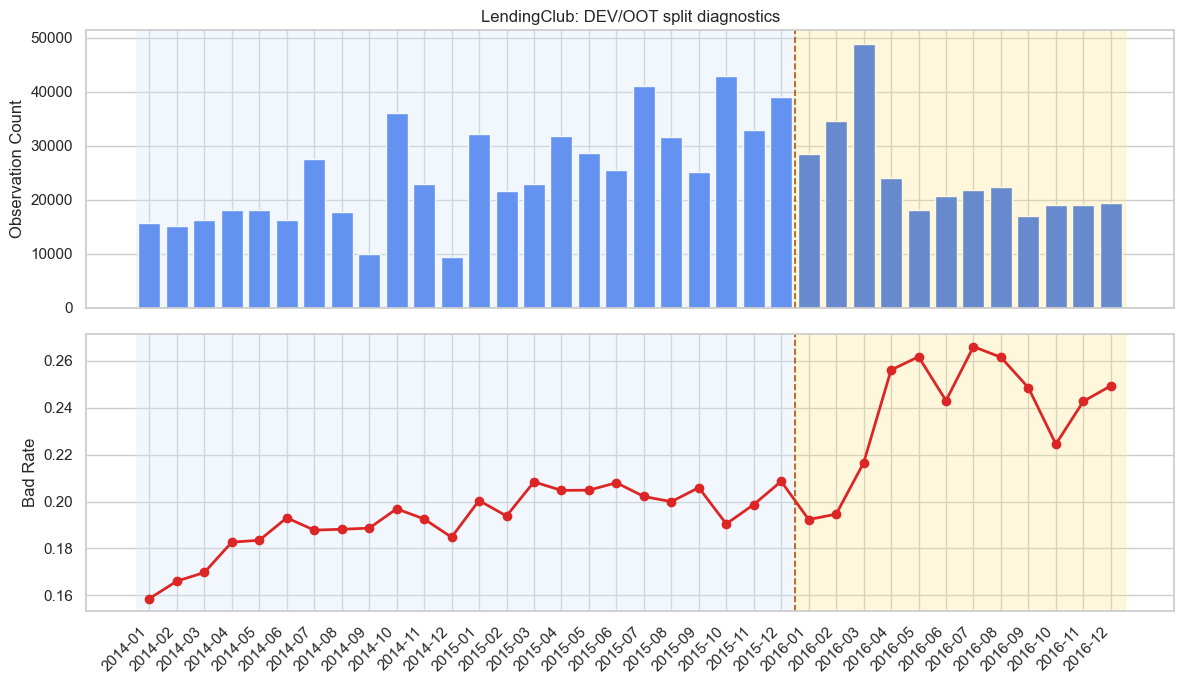

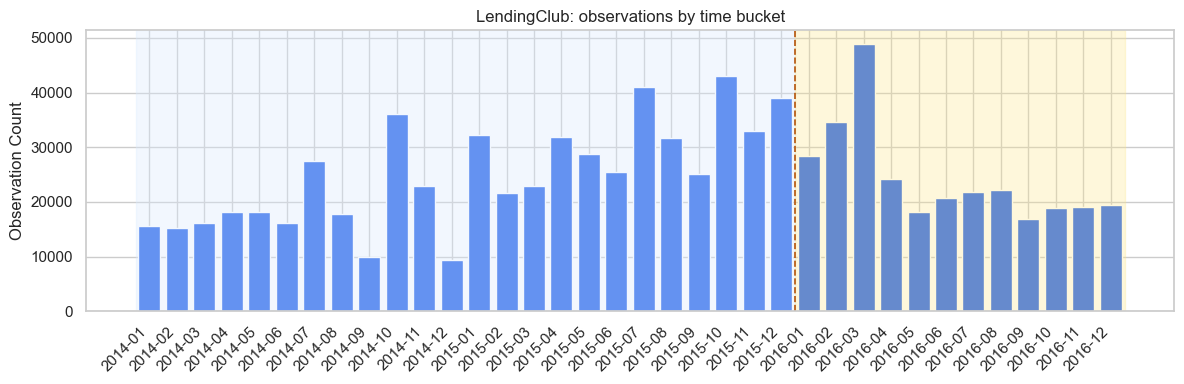

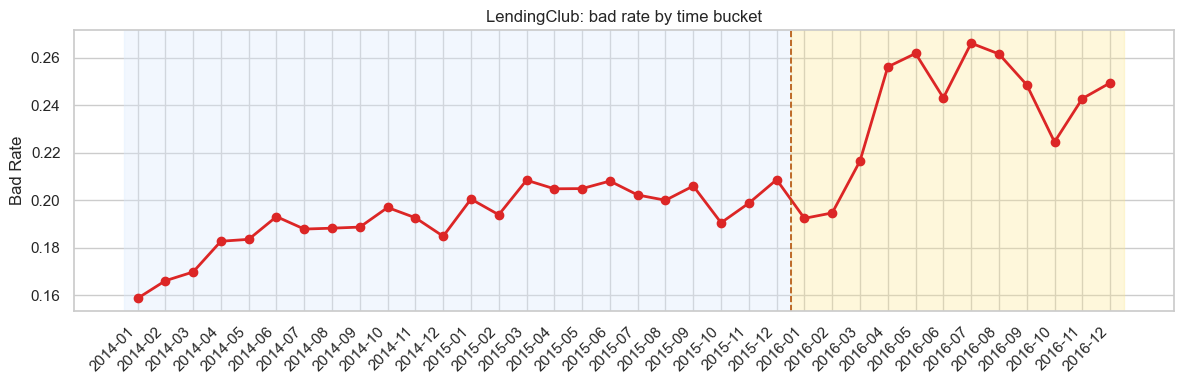

In [6]:
plot_dev_oot_split_diagnostics(dataset_name)
plot_observation_count_by_time(dataset_name)
plot_bad_rate_by_time(dataset_name)

## 6a. LendingClub Monthly Split Diagnostic

This plot connects the DEV/OOT split rationale to monthly observation counts and bad-rate movement.

,issue_month,split_segment,observation_count,bad_rate
0,2014-01,DEV,15614,0.1586
1,2014-02,DEV,15205,0.1661
2,2014-03,DEV,16194,0.1698
3,2014-04,DEV,18172,0.1827
4,2014-05,DEV,18098,0.1835
5,2014-06,DEV,16186,0.1931
6,2014-07,DEV,27547,0.1878
7,2014-08,DEV,17731,0.1882
8,2014-09,DEV,9960,0.1887
9,2014-10,DEV,36072,0.1969


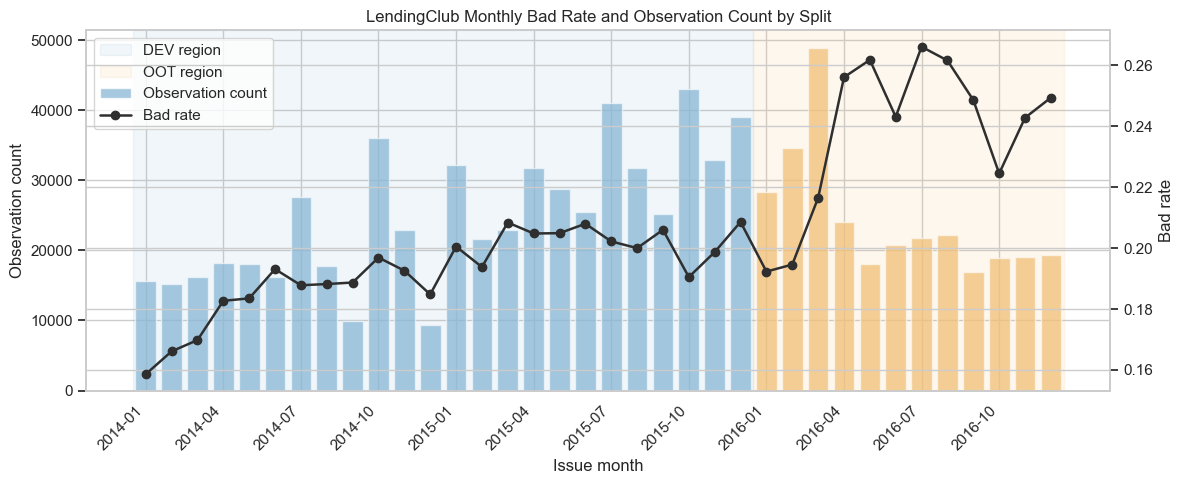

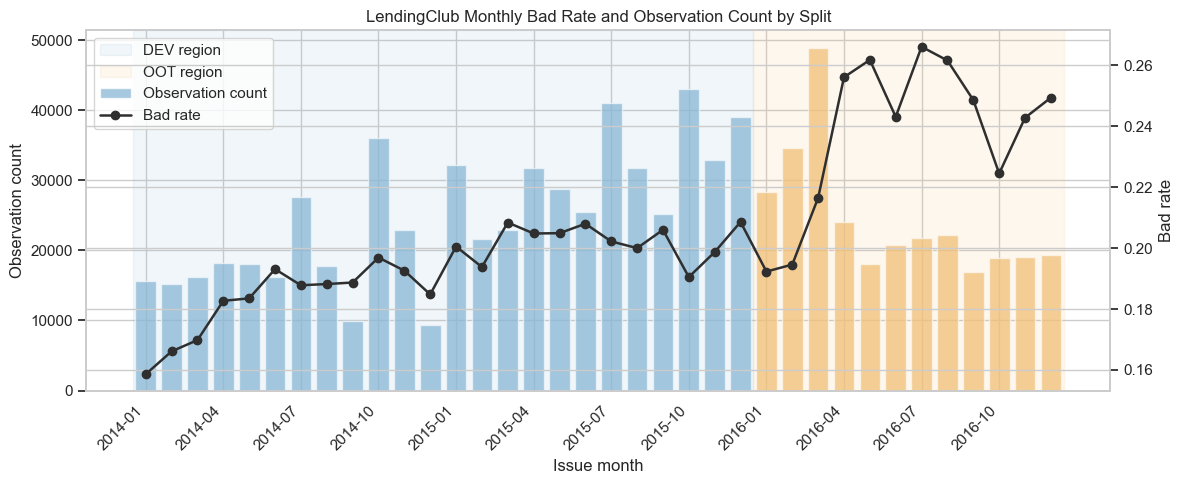

In [7]:
monthly_split = lendingclub_monthly_bad_rate_observation_count_table()
display(monthly_split)
plot_lendingclub_monthly_bad_rate_observation_count(monthly_split)

## 7. Experiment Matrix Overview

In [8]:
display(inputs['matrix_overview'])
failed_run_columns = [column for column in ['run_id', 'model', 'selector', 'experiment_type', 'status', 'error', 'failed_at'] if column in inputs['failed_runs'].columns]
display(inputs['failed_runs'][failed_run_columns])

,dataset,models,selectors,feature_budgets,completed_run_count,failed_run_count
0,lendingclub,"catboost, lr","mrmr, boruta, pca, domain_rule_baseline, llm, ...","20, 40",16,0


,run_id,model,selector,experiment_type,status,error,failed_at


## 8. Topline Performance Comparison

,model,selector,experiment_type,oot_auc,oot_gini,oot_ks,lift_at_10,selected_feature_count,runtime_seconds,model_score_psi
0,lr,llm,llm,0.6982,0.3965,0.2830,2.1306,20.0,353.2234,0.0058
1,lr,llm_then_mrmr,hybrid,0.6940,0.3881,0.2780,2.1082,20.0,273.5664,0.0051
2,lr,pca,statistical,0.6918,0.3835,0.2770,2.0954,20.0,81.8562,0.0139
3,lr,mrmr,statistical,0.6908,0.3816,0.2750,2.0998,20.0,428.6104,0.0042
4,lr,stable_core_llm_fill,hybrid,0.6907,0.3815,0.2735,2.0976,20.0,1705.7226,0.0040
5,lr,llm_then_boruta,hybrid,0.6534,0.3069,0.2219,1.7696,20.0,2110.3166,0.0078
6,lr,boruta,statistical,0.6350,0.2700,0.1977,1.6931,20.0,4143.0061,0.0079
7,lr,domain_rule_baseline,statistical,0.6199,0.2399,0.1734,1.6130,20.0,58.3984,0.0242
8,catboost,llm,llm,0.7165,0.4329,0.3103,2.2538,40.0,3624.1757,0.0055
9,catboost,llm_then_mrmr,hybrid,0.7071,0.4143,0.2973,2.2009,40.0,3581.0058,0.0071


LendingClub acts as external validation, and the OOT leaderboard is tighter than on Home Credit. For LR, `llm` is best on OOT AUC (0.6982); for CatBoost, `llm` is best at 0.7165. The strongest non-LLM baseline is `mrmr` at 0.7060. The headline is not universal dominance: the best LLM-family methods sit near the top, but the margins over mRMR are modest. Paired-fold CV deltas versus the mRMR baseline were positive (mean AUC delta 0.0007, 95% CI 0.0001 to 0.0012). Paired-fold CV deltas versus the mRMR baseline were inconclusive (mean AUC delta 0.0003, 95% CI -0.0115 to 0.0121).

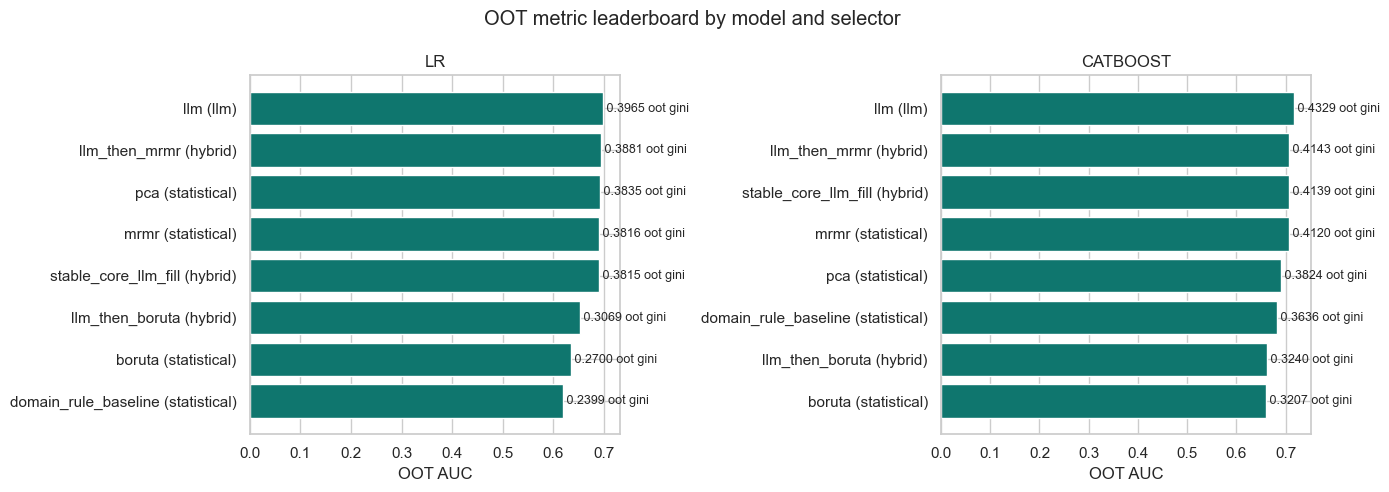

In [9]:
leaderboard_columns = [
    'model', 'selector', 'experiment_type', 'oot_auc', 'oot_gini', 'oot_ks',
    'lift_at_10', 'selected_feature_count', 'runtime_seconds', 'model_score_psi',
]
display(final_comparison[[column for column in leaderboard_columns if column in final_comparison.columns]].head(16))
plot_metric_leaderboard(final_comparison)
display(Markdown(findings['topline_markdown']))

## 9. Paired Fold Significance

In [10]:
display(paired_significance)

,dataset,model,candidate_selector,baseline_selector,metric,mean_delta,std_delta,ttest_p_value,wilcoxon_p_value,significant_at_0_05,interpretation
6,lendingclub,catboost,stable_core_llm_fill,mrmr,auc,0.0007,0.0006,0.0729,0.1250,False,Mean fold AUC delta is tiny and not statistica...
7,lendingclub,catboost,llm,mrmr,auc,0.0003,0.0134,0.9658,0.6250,False,Mean fold AUC delta is tiny and not statistica...
8,lendingclub,catboost,llm_then_mrmr,mrmr,auc,0.0000,0.0015,0.9429,0.8125,False,Mean fold AUC delta is tiny and not statistica...
9,lendingclub,lr,stable_core_llm_fill,mrmr,auc,0.0001,0.0013,0.8913,0.8125,False,Mean fold AUC delta is tiny and not statistica...
10,lendingclub,lr,llm,mrmr,auc,-0.0027,0.0171,0.7429,0.6250,False,"Mean fold AUC is lower than mRMR, but not stat..."
11,lendingclub,lr,llm_then_mrmr,mrmr,auc,0.0014,0.0017,0.1483,0.1875,False,Mean fold AUC delta is tiny and not statistica...


## 10. Stability Review

,dataset_name,model,selector,experiment_type,nogueira_stability,kuncheva_stability,mean_pairwise_jaccard,semantic_group_jaccard,stable_feature_count_80,stable_feature_ratio_80,stable_semantic_group_count_80,semantic_group_stable_ratio_80,spearman_rank_stability_mean,kendall_rank_stability_mean,rbo_rank_stability_mean
0,lendingclub,catboost,pca,statistical,1.0000,1.0000,1.0000,1.0000,40.0,1.000,1.0,1.00,1.0000,1.0000,NaN
1,lendingclub,catboost,domain_rule_baseline,statistical,1.0000,1.0000,1.0000,1.0000,40.0,1.000,5.0,1.00,1.0000,1.0000,NaN
2,lendingclub,catboost,llm_then_mrmr,hybrid,0.8096,0.8096,0.7197,0.8500,32.0,0.800,3.0,1.00,0.5590,0.4256,NaN
3,lendingclub,catboost,mrmr,statistical,0.7981,0.7981,0.7081,0.9000,34.0,0.850,3.0,1.00,0.7425,0.5607,NaN
4,lendingclub,catboost,stable_core_llm_fill,hybrid,0.7779,0.7779,0.6834,1.0000,33.0,0.825,3.0,1.00,0.5590,0.4256,NaN
5,lendingclub,catboost,llm_then_boruta,hybrid,0.7288,0.7288,0.6421,0.8500,31.0,0.775,3.0,1.00,0.5590,0.4256,NaN
6,lendingclub,catboost,llm,llm,0.7288,0.7288,0.6230,0.8000,28.0,0.700,2.0,1.00,0.5590,0.4256,NaN
7,lendingclub,catboost,boruta,statistical,0.7029,0.7029,0.6179,0.7150,28.0,0.700,3.0,0.75,0.5695,0.5339,NaN
8,lendingclub,lr,pca,statistical,1.0000,1.0000,1.0000,1.0000,20.0,1.000,1.0,1.00,1.0000,1.0000,NaN
9,lendingclub,lr,domain_rule_baseline,statistical,1.0000,1.0000,1.0000,1.0000,20.0,1.000,2.0,1.00,1.0000,1.0000,NaN


The stability picture is better for the stronger hybrids than for the pure LLM selector. `domain_rule_baseline` on `catboost` has the highest saved Nogueira stability at 1.0000. Again, perfect-repeatability selectors such as PCA should not be overread: semantic concentration and weak robustness matter more than exact repeatability alone.

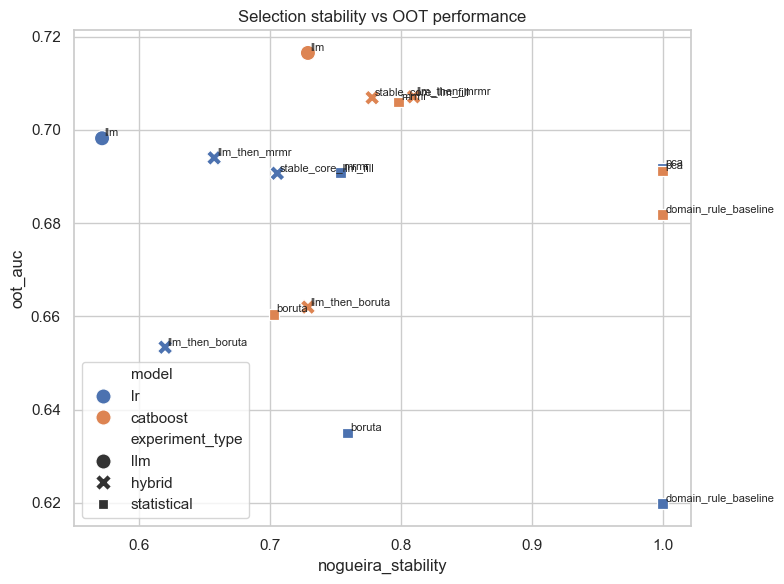

In [11]:
display(stability.head(16))
plot_stability_vs_performance(stability, final_comparison)
display(Markdown(findings['stability_markdown']))

## 11. Drift and Robustness Review

,dataset_name,model,selector,experiment_type,selected_feature_psi_mean,selected_feature_psi_max,selected_feature_psi_median,selected_feature_psi_high_drift_ratio,selected_feature_psi_moderate_or_high_drift_ratio,model_score_psi
0,lendingclub,catboost,llm,llm,0.0027,0.0357,0.0000,0.0000,0.0000,0.0055
1,lendingclub,catboost,boruta,statistical,0.0039,0.0344,0.0000,0.0000,0.0000,0.0038
2,lendingclub,catboost,llm_then_boruta,hybrid,0.0044,0.0344,0.0000,0.0000,0.0000,0.0029
3,lendingclub,catboost,mrmr,statistical,0.0060,0.0331,0.0011,0.0000,0.0000,0.0073
4,lendingclub,catboost,llm_then_mrmr,hybrid,0.0061,0.0331,0.0013,0.0000,0.0000,0.0071
5,lendingclub,catboost,stable_core_llm_fill,hybrid,0.0063,0.0331,0.0012,0.0000,0.0000,0.0074
6,lendingclub,catboost,domain_rule_baseline,statistical,0.0098,1.2304,0.0000,0.0073,0.0073,0.0012
7,lendingclub,catboost,pca,statistical,1.0802,9.7747,0.5816,0.6750,0.8250,0.0279
8,lendingclub,lr,domain_rule_baseline,statistical,0.0012,0.0193,0.0000,0.0000,0.0000,0.0242
9,lendingclub,lr,llm,llm,0.0021,0.0357,0.0000,0.0000,0.0000,0.0058


,dataset,model,selector,selected_feature_count,psi_mean,psi_median,psi_p75,psi_p90,psi_p95,psi_max,high_psi_feature_count,high_psi_feature_ratio
0,lendingclub,catboost,llm,117,0.0027,0.0000,0.0011,0.0093,0.0162,0.0357,0,0.0000
1,lendingclub,catboost,boruta,40,0.0039,0.0000,0.0016,0.0161,0.0281,0.0344,0,0.0000
2,lendingclub,catboost,llm_then_boruta,40,0.0044,0.0000,0.0041,0.0161,0.0281,0.0344,0,0.0000
3,lendingclub,catboost,mrmr,40,0.0060,0.0011,0.0059,0.0189,0.0255,0.0331,0,0.0000
4,lendingclub,catboost,llm_then_mrmr,40,0.0061,0.0013,0.0059,0.0189,0.0255,0.0331,0,0.0000
5,lendingclub,catboost,stable_core_llm_fill,40,0.0063,0.0012,0.0069,0.0198,0.0255,0.0331,0,0.0000
6,lendingclub,catboost,domain_rule_baseline,137,0.0098,0.0000,0.0000,0.0004,0.0056,1.2304,1,0.0073
7,lendingclub,catboost,pca,40,1.0802,0.5816,1.4180,2.2712,2.6224,9.7747,27,0.6750
8,lendingclub,lr,domain_rule_baseline,40,0.0012,0.0000,0.0000,0.0005,0.0128,0.0193,0,0.0000
9,lendingclub,lr,llm,85,0.0021,0.0000,0.0000,0.0068,0.0146,0.0357,0,0.0000


,dataset,model,selector,run_id,feature,semantic_group,psi_dev_oot,rank_within_pipeline,reason_flag
0,lendingclub,catboost,domain_rule_baseline,catboost_statistical_domain_rule_baseline_6038...,bankcard_capacity_gap,income_capacity,1.2304,1.0,PSI >= 0.25
1,lendingclub,catboost,pca,catboost_statistical_pca_0952e619b24c,PC1,pca_component,9.7747,1.0,PSI >= 0.25
2,lendingclub,catboost,pca,catboost_statistical_pca_0952e619b24c,PC9,pca_component,3.4746,2.0,PSI >= 0.25
3,lendingclub,catboost,pca,catboost_statistical_pca_0952e619b24c,PC19,pca_component,2.5775,3.0,PSI >= 0.25
4,lendingclub,catboost,pca,catboost_statistical_pca_0952e619b24c,PC38,pca_component,2.3609,4.0,PSI >= 0.25
5,lendingclub,catboost,pca,catboost_statistical_pca_0952e619b24c,PC14,pca_component,2.2612,5.0,PSI >= 0.25
6,lendingclub,catboost,pca,catboost_statistical_pca_0952e619b24c,PC8,pca_component,2.1937,6.0,PSI >= 0.25
7,lendingclub,catboost,pca,catboost_statistical_pca_0952e619b24c,PC29,pca_component,2.1819,7.0,PSI >= 0.25
8,lendingclub,catboost,pca,catboost_statistical_pca_0952e619b24c,PC26,pca_component,2.0005,8.0,PSI >= 0.25
9,lendingclub,catboost,pca,catboost_statistical_pca_0952e619b24c,PC30,pca_component,1.9568,9.0,PSI >= 0.25


,dataset,model,run_id,feature,in_llm_top_pool,in_final_selected_set,psi_dev_oot,semantic_group,source_table,missing_from_dev_oot_reason
129,lendingclub,catboost,catboost_hybrid_llm_then_mrmr_429b32e00b37,total_bc_limit_per_bc_trade,True,True,0.0331,other,NaN,NaN
114,lendingclub,catboost,catboost_hybrid_llm_then_mrmr_429b32e00b37,acc_open_past_24mths_share,True,True,0.0279,other,NaN,NaN
103,lendingclub,catboost,catboost_hybrid_llm_then_mrmr_429b32e00b37,bc_open_to_buy,True,True,0.0256,other,NaN,NaN
147,lendingclub,catboost,catboost_hybrid_llm_then_mrmr_429b32e00b37,total_rev_hi_lim_per_rev_trade,True,True,0.0247,other,NaN,NaN
108,lendingclub,catboost,catboost_hybrid_llm_then_mrmr_429b32e00b37,loan_to_total_limit,True,True,0.0182,other,NaN,NaN
132,lendingclub,catboost,catboost_hybrid_llm_then_mrmr_429b32e00b37,num_tl_op_past_12m_share,True,True,0.0182,other,NaN,NaN
82,lendingclub,catboost,catboost_hybrid_llm_then_mrmr_429b32e00b37,num_tl_op_past_12m,True,True,0.0157,other,NaN,NaN
95,lendingclub,catboost,catboost_hybrid_llm_then_mrmr_429b32e00b37,acc_open_past_24mths,True,True,0.0150,other,NaN,NaN
77,lendingclub,catboost,catboost_hybrid_llm_then_mrmr_429b32e00b37,loan_to_income,True,True,0.0126,income_capacity,NaN,NaN
87,lendingclub,catboost,catboost_hybrid_llm_then_mrmr_429b32e00b37,mort_acc,True,True,0.0090,other,NaN,NaN


,dataset,model,selector,run_id,feature,llm_rank,in_llm_top100,in_final_selected_set,selected_by_downstream_stat_selector,semantic_group,source_table,psi_dev_oot,psi_flag,missing_from_dev_oot_reason
0,lendingclub,catboost,llm,catboost_llm_llm_fe14a4902388,fico_mean,1,True,True,False,other,NaN,0.0049,low,NaN
1,lendingclub,catboost,llm,catboost_llm_llm_fe14a4902388,loan_to_income,2,True,True,False,income_capacity,NaN,0.0126,low,NaN
2,lendingclub,catboost,llm,catboost_llm_llm_fe14a4902388,dti,3,True,True,False,other,NaN,0.0011,low,NaN
3,lendingclub,catboost,llm,catboost_llm_llm_fe14a4902388,term,4,True,True,False,other,NaN,NaN,unavailable,numeric_dev_oot_values_unavailable
4,lendingclub,catboost,llm,catboost_llm_llm_fe14a4902388,home_ownership,5,True,True,False,other,NaN,NaN,unavailable,numeric_dev_oot_values_unavailable
5,lendingclub,catboost,llm,catboost_llm_llm_fe14a4902388,addr_state,6,True,True,False,other,NaN,NaN,unavailable,numeric_dev_oot_values_unavailable
6,lendingclub,catboost,llm,catboost_llm_llm_fe14a4902388,num_tl_op_past_12m,7,True,True,False,other,NaN,0.0157,low,NaN
7,lendingclub,catboost,llm,catboost_llm_llm_fe14a4902388,mths_since_recent_inq,8,True,True,False,other,NaN,0.0012,low,NaN
8,lendingclub,catboost,llm,catboost_llm_llm_fe14a4902388,total_bal_ex_mort_to_income,9,True,True,False,income_capacity,NaN,0.0004,low,NaN
9,lendingclub,catboost,llm,catboost_llm_llm_fe14a4902388,tot_hi_cred_lim_to_income,10,True,True,False,income_capacity,NaN,0.0008,low,NaN


Drift on LendingClub is generally low for the best methods, which is encouraging for the external-validation claim. The best low-drift run in the drift table is `domain_rule_baseline` on `lr` with mean feature PSI 0.0012. PCA is the obvious exception and should be flagged explicitly because its feature PSI is much higher than the rest of the table.

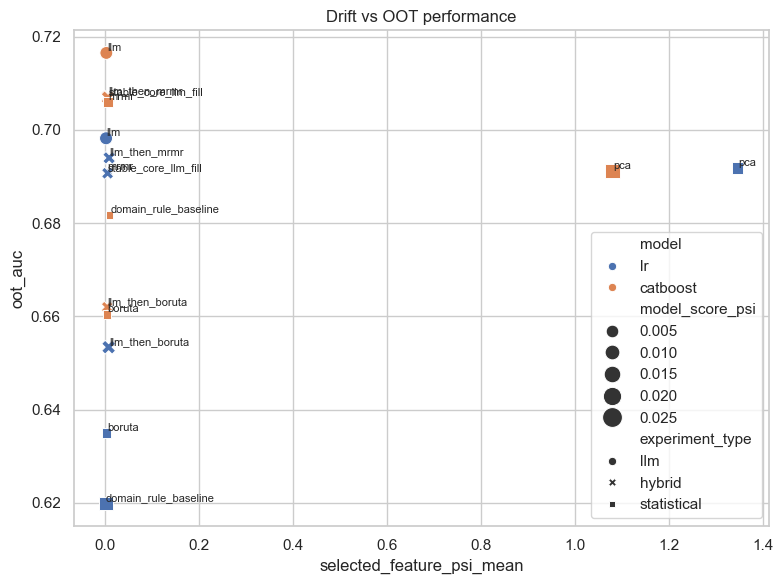

In [12]:
display(drift.head(16))
display(psi_distribution.head(16))
display(high_psi_features.head(20))
display(llm_then_mrmr_drift.head(20))
display(llm_top100_candidate_psi.head(30))
plot_drift_vs_performance(drift, final_comparison)
display(Markdown(findings['drift_markdown']))

## 12. Semantic Coverage and Redundancy Review

,dataset_name,run_id,model,selector,experiment_type,semantic_group,feature_count,feature_ratio
0,lendingclub,catboost_llm_llm_fe14a4902388,catboost,llm,llm,income_capacity,8,0.200
1,lendingclub,catboost_llm_llm_fe14a4902388,catboost,llm,llm,revolving_utilization,7,0.175
2,lendingclub,catboost_llm_llm_fe14a4902388,catboost,llm,llm,account_opening_activity,6,0.150
3,lendingclub,catboost_llm_llm_fe14a4902388,catboost,llm,llm,loan_terms,6,0.150
4,lendingclub,catboost_llm_llm_fe14a4902388,catboost,llm,llm,bankcard_capacity,3,0.075
5,lendingclub,catboost_llm_llm_fe14a4902388,catboost,llm,llm,exposure_amount,2,0.050
6,lendingclub,catboost_llm_llm_fe14a4902388,catboost,llm,llm,mortgage_history,2,0.050
7,lendingclub,catboost_llm_llm_fe14a4902388,catboost,llm,llm,other,2,0.050
8,lendingclub,catboost_llm_llm_fe14a4902388,catboost,llm,llm,recent_inquiries,2,0.050
9,lendingclub,catboost_llm_llm_fe14a4902388,catboost,llm,llm,credit_history_length,1,0.025


,dataset,model,selector,selected feature count,number of semantic groups,semantic group entropy if easy,largest group share,average within-group absolute correlation,max within-group absolute correlation,redundancy risk flag
0,lendingclub,catboost,llm,40,11,2.1739,0.20,0.3513,0.9820,high_max_correlation
1,lendingclub,catboost,llm_then_mrmr,40,9,1.9339,0.35,0.7501,1.0000,high_max_correlation
2,lendingclub,catboost,mrmr,40,10,2.0234,0.25,0.6732,1.0000,high_max_correlation
3,lendingclub,catboost,stable_core_llm_fill,40,8,1.9434,0.25,0.6732,1.0000,high_max_correlation
4,lendingclub,lr,llm,20,9,2.0127,0.25,0.3967,0.7583,moderate
5,lendingclub,lr,llm_then_mrmr,20,8,1.8344,0.30,0.4493,0.7583,moderate
6,lendingclub,lr,mrmr,20,5,1.4878,0.40,1.0000,1.0000,high_max_correlation
7,lendingclub,lr,stable_core_llm_fill,20,6,1.6385,0.35,0.8791,1.0000,high_max_correlation


Semantic diversity on LendingClub is more interpretable after the report-layer mapping update, because common credit-score, capacity, revolving-utilization, bankcard, and account-activity features no longer collapse unnecessarily into `other`. This relabeling improves the semantic coverage evidence but does not change feature selection results. The safer reading is that some LLM-family methods remain performance-competitive under a leakage-audited external dataset, while semantic coverage remains dataset and rule dependent.

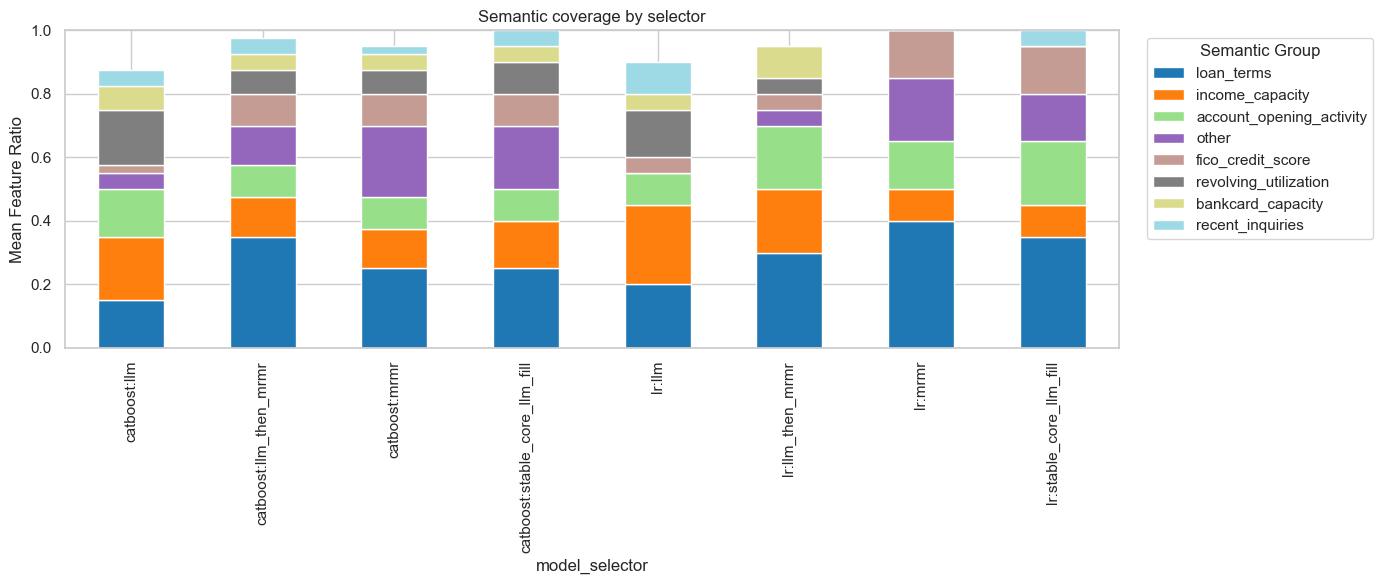

In [13]:
display(semantic_coverage.head(30))
display(semantic_redundancy)
plot_semantic_coverage(semantic_coverage)
display(Markdown(findings['semantic_markdown']))

## 13. Efficiency Tradeoff

,dataset,LLM calls made,cache hits,total tokens,prompt version,shared ranking enabled,number of runs sharing ranking
0,lendingclub,6,42,66020,stability_expert_v3,True,8


Efficiency is a more serious tradeoff on LendingClub. Boruta is expensive and weak, while the best LLM-family CatBoost runs are competitive but substantially slower than the best LR runs. The cache behavior still helps: the saved artifacts record 42 cache hits and 66020 total tokens, which indicates that shared ranking and reuse reduce repeated LLM cost.

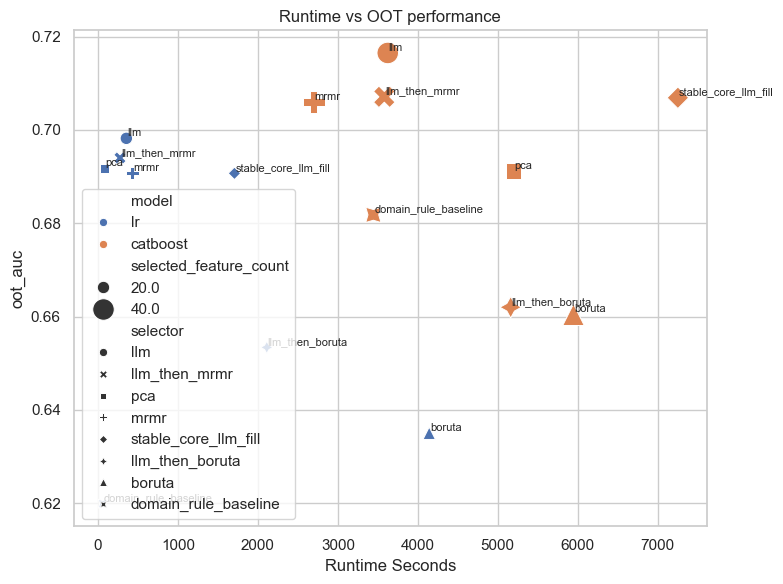

In [14]:
display(inputs['llm_call_summary'])
plot_runtime_tradeoff(final_comparison)
display(Markdown(findings['efficiency_markdown']))

## 14. Best Runs Deep Dive

In [15]:
display(best_runs)

if run_artifacts:
    display(run_artifacts.get('summary_table').drop(columns=['exp_dir'], errors='ignore'))
    display(run_artifacts.get('oot_results'))
    display(run_artifacts.get('selected_features').head(20))
    display(run_artifacts.get('semantic_group_summary'))
    display(run_artifacts.get('warnings'))

,analysis_label,run_id,model,selector,experiment_type,OOT_AUC,OOT_Gini,OOT_KS,CV_AUC_mean,CV_AUC_std,selected_feature_count,top_features,top_semantic_groups,fold_behavior,why_it_matters
0,best LR run,lr_llm_llm_94542581466b,lr,llm,llm,0.6982,0.3965,0.2830,0.7121,0.0230,20.0,"fico_mean, loan_to_income, dti, term, home_own...","income_capacity (5), loan_terms (4), revolving...",CV AUC 0.7121 +/- 0.0230,highest OOT leaderboard entry for this slice
1,best CatBoost run,catboost_llm_llm_fe14a4902388,catboost,llm,llm,0.7165,0.4329,0.3103,0.7247,0.0227,40.0,"fico_mean, loan_to_income, dti, term, home_own...","income_capacity (8), revolving_utilization (7)...",CV AUC 0.7247 +/- 0.0227,highest OOT leaderboard entry for this slice
2,strongest non-LLM baseline,catboost_statistical_mrmr_e9152da1cab6,catboost,mrmr,statistical,0.7060,0.4120,0.2953,0.7244,0.0102,40.0,"term_36 months, acc_open_past_24mths_share, dt...","loan_terms (10), other (9), income_capacity (5)",CV AUC 0.7244 +/- 0.0102,reference baseline for non-LLM comparison


,method,model_name,selector_name,cv_fold_count,cv_auc_mean,cv_auc_std,cv_gini_mean,cv_gini_std,cv_ks_mean,cv_ks_std,...,semantic_group_stable_ratio_80,total_candidate_feature_count,spearman_rank_stability_mean,spearman_rank_stability_std,kendall_rank_stability_mean,kendall_rank_stability_std,rbo_rank_stability_mean,rbo_rank_stability_std,final_selected_feature_count,runtime_seconds
0,llm,lr,llm,5,0.7121,0.023,0.4242,0.0461,0.3082,0.0335,...,1.0,300.0,0.559,0.1645,0.4256,0.1482,NaN,NaN,20,353.2234


,gini,auc,ks,ks_threshold,decision_threshold,tn,fp,fn,tp,precision,...,selected_feature_psi_mean,selected_feature_psi_max,selected_feature_psi_median,selected_feature_psi_high_drift_ratio,selected_feature_psi_moderate_or_high_drift_ratio,model_score_psi,lift_at_10,bad_rate_capture_at_10,lift_at_20,bad_rate_capture_at_20
0,0.3965,0.6982,0.283,0.4496,0.4902,155681,69172,28249,40003,0.3664,...,0.0021,0.0357,0.0,0.0,0.0,0.0058,2.1306,0.2131,1.8495,0.3699


,fold_id,selector,feature_name,feature,semantic_group,rank,score
0,final_dev,llm,fico_mean,fico_mean,fico_credit_score,1,NaN
1,final_dev,llm,loan_to_income,loan_to_income,income_capacity,2,NaN
2,final_dev,llm,dti,dti,income_capacity,3,NaN
3,final_dev,llm,term,term,loan_terms,4,NaN
4,final_dev,llm,home_ownership,home_ownership,loan_terms,5,NaN
5,final_dev,llm,addr_state,addr_state,loan_terms,6,NaN
6,final_dev,llm,num_tl_op_past_12m,num_tl_op_past_12m,account_opening_activity,7,NaN
7,final_dev,llm,mths_since_recent_inq,mths_since_recent_inq,recent_inquiries,8,NaN
8,final_dev,llm,total_bal_ex_mort_to_income,total_bal_ex_mort_to_income,income_capacity,9,NaN
9,final_dev,llm,tot_hi_cred_lim_to_income,tot_hi_cred_lim_to_income,income_capacity,10,NaN


,semantic_group,feature_count,feature_ratio
4,income_capacity,5,0.25
5,loan_terms,4,0.20
8,revolving_utilization,3,0.15
0,account_opening_activity,2,0.10
7,recent_inquiries,2,0.10
3,fico_credit_score,1,0.05
2,exposure_amount,1,0.05
1,bankcard_capacity,1,0.05
6,mortgage_history,1,0.05


[]

## 15. Leakage and Temporal Governance

In [16]:
display(Markdown(governance_note))

# LendingClub Leakage And Label Definition

## Target Definition

`TARGET = 1` for final bad/default outcomes and `TARGET = 0` for final good outcomes. The implementation is in `src/credit_risk_fs/preprocessing/labeling.py`.

Good statuses:
- `Does not meet the credit policy. Status:Fully Paid`
- `Fully Paid`

Bad/default statuses:
- `Charged Off`
- `Default`
- `Does not meet the credit policy. Status:Charged Off`

Dropped ambiguous/current/unmatured statuses:
- `Current`
- `In Grace Period`
- `Issued`
- `Late (16-30 days)`
- `Late (31-120 days)`

## Leakage Columns Removed

payment fields:
- `total_pymnt` (not present in processed safe file)
- `total_pymnt_inv` (not present in processed safe file)
- `total_rec_prncp` (not present in processed safe file)
- `total_rec_int` (not present in processed safe file)
- `total_rec_late_fee` (not present in processed safe file)
- `last_pymnt_amnt` (not present in processed safe file)

recovery fields:
- `recoveries` (not present in processed safe file)
- `collection_recovery_fee` (not present in processed safe file)

settlement fields:
- `debt_settlement_flag` (not present in processed safe file)
- `debt_settlement_flag_date` (not present in processed safe file)
- `settlement_status` (not present in processed safe file)
- `settlement_date` (not present in processed safe file)
- `settlement_amount` (not present in processed safe file)
- `settlement_percentage` (not present in processed safe file)
- `settlement_term` (not present in processed safe file)

hardship fields:
- `hardship_flag` (not present in processed safe file)
- `hardship_type` (not present in processed safe file)
- `hardship_reason` (not present in processed safe file)
- `hardship_status` (not present in processed safe file)
- `hardship_amount` (not present in processed safe file)
- `hardship_start_date` (not present in processed safe file)
- `hardship_end_date` (not present in processed safe file)
- `hardship_length` (not present in processed safe file)
- `hardship_dpd` (not present in processed safe file)
- `hardship_loan_status` (not present in processed safe file)
- `hardship_payoff_balance_amount` (not present in processed safe file)
- `hardship_last_payment_amount` (not present in processed safe file)

post-origination status fields:
- `loan_status` (not present in processed safe file)
- `grade` (not present in processed safe file)
- `sub_grade` (not present in processed safe file)
- `int_rate` (not present in processed safe file)
- `installment` (not present in processed safe file)
- `funded_amnt` (not present in processed safe file)
- `funded_amnt_inv` (not present in processed safe file)
- `pymnt_plan` (not present in processed safe file)
- `disbursement_method` (not present in processed safe file)

collection fields:
- `collection_recovery_fee` (not present in processed safe file)

future payment/date fields:
- `last_pymnt_d` (not present in processed safe file)
- `next_pymnt_d` (not present in processed safe file)
- `last_credit_pull_d` (not present in processed safe file)
- `last_fico_range_low` (not present in processed safe file)
- `last_fico_range_high` (not present in processed safe file)
- `payment_plan_start_date` (not present in processed safe file)

Collection-count fields retained as application-time credit-history variables, not post-outcome recovery leakage:
- `collections_12_mths_ex_med`
- `sec_app_collections_12_mths_ex_med`

## Processed Safe Path Evidence

- Processed file: `data\lendingclub\processed\application_train.csv`.
- Processed CSV column count: `99`.
- Final processed feature count after excluding `TARGET`, `recent_decision`, `issue_d`, and `loan_status`: `96`.
- `loan_status` present in processed CSV: `False`.
- `TARGET` present in processed CSV: `True`.
- `recent_decision` present in processed CSV for temporal splitting: `True`.
- `issue_d` present in processed CSV but configured as excluded before modeling: `True`.
- Current reported LendingClub matrix rows use the processed safe path: `True`.

Run-level `leakage_report.json` artifacts confirm `target_column_excluded=true`, empty forbidden-column lists in train/OOT features, and `oot_used_in_feature_selection=false`.

## Missingness-By-Target Check

- Rows checked: `1348099`.
- Good rows: `1078739`.
- Bad rows: `269360`.
- Possible leakage flags from missingness asymmetry: `0`.
- Output table: `results/lendingclub/analysis/leakage_transparency/missingness_by_target_leakage_check.csv`.

No missingness-by-target possible leakage flags were found under the configured threshold.

Plots:
- Skipped `missingness_by_target_possible_leakage_flags.png`: no possible leakage flags.

## Remaining Items

- The processed safe file keeps `TARGET` for supervised training and `recent_decision`/`issue_d` for time handling, but experiment configs exclude these from model features.
- Raw LendingClub files remain leakage-prone and should not be used directly without the preparation/audit path.


## 16. Failure Cases and Surprises

In [17]:
display(Markdown(findings['failure_markdown']))

The main failure cases are again Boruta and PCA, with `llm_then_boruta` also clearly underperforming. LendingClub carries a separate data-governance caveat: the current processed dataset is the safe path, while raw direct use should remain blocked or tightly audited because the raw files contain post-origination leakage fields. OOT has a higher bad rate than DEV, making the OOT period a harder external validation period while still retaining enough observations in both windows.

## 17. Conclusions for This Dataset

In [18]:
display(Markdown(findings['conclusion_markdown']))

On LendingClub, the honest claim is still moderate: LLM screening is useful as a first-stage helper, but it does not universally dominate the statistical baselines. The carry-forward methods for cross-dataset discussion are the best OOT LLM-family variant together with mRMR as the stability-aware non-LLM reference. The evidence is mixed, with small performance gaps, useful drift behavior, and only limited semantic-coverage separation.

## 18. Future CLIP-Style Validation Placeholder

In [19]:
display(Markdown(clip_placeholder['summary']))
display(clip_placeholder['artifacts'])

This section is a reserved placeholder for future CLIP-style semantic-statistical feature alignment. It is not image CLIP and is not implemented here. The future method would align feature text and metadata with empirical feature behavior in a shared representation space, using DEV-only evidence and comparing the resulting screener against the current selectors under the same DEV/OOT protocol. OOT metrics must not be used for CLIP-style training or feature selection; they remain final evaluation only.

,planned_artifact,purpose,status,notes
0,feature_level_evidence.csv,one row per feature with semantic and empirica...,available,generated from current aggregate and per-run a...
1,contrastive_pairs.csv,"positive, hard-negative, and easy-negative fea...",planned,pairs should be constructed from DEV-only evid...
2,clip_embedding_table.csv,learned feature embeddings and similarity to a...,planned,dual-encoder or contrastive feature-space output
3,clip_vs_llm_vs_mrmr_comparison.csv,compare the future CLIP-style screener against...,planned,must be evaluated under the same DEV/OOT protocol


## 19. Saved Final-Report Plots

In [20]:
display(plot_manifest)

,plot_file,source_table,rows_used,columns_used,purpose,status,skip_reason
0,dev_oot_split_diagnostics.png,derived time-bucket summary,36,time_bucket;split_segment;observation_count;ba...,Show DEV/OOT observation counts and bad-rate b...,created,
1,observation_count_by_time.png,derived time-bucket summary,36,time_bucket;observation_count;split_segment,Show observations available by time bucket.,created,
2,bad_rate_by_time.png,derived time-bucket summary,36,time_bucket;bad_rate;split_segment,Show target-rate behavior by time bucket.,created,
3,metric_leaderboard_oot_auc.png,final_comparison_table.csv,16,model;selector;experiment_type;oot_auc;oot_gini,Compare OOT AUC leaderboard by model and selec...,created,
4,stability_vs_performance.png,final_comparison_table.csv + feature_stability...,16,model;selector;experiment_type;oot_auc;nogueir...,Compare exact feature stability against OOT AUC.,created,
5,drift_vs_performance.png,final_comparison_table.csv + feature_drift_tab...,16,model;selector;experiment_type;oot_auc;selecte...,Compare selected-feature PSI against OOT AUC.,created,
6,semantic_coverage.png,analysis/semantic_redundancy/semantic_coverage...,66,model;selector;semantic_group;feature_ratio,Show semantic group mix by selector.,created,
7,runtime_tradeoff.png,final_comparison_table.csv,16,runtime_seconds;oot_auc;model;selector;selecte...,"Compare runtime, feature count, and OOT AUC.",created,
8,lendingclub_monthly_bad_rate_observation_count...,final_report/split_diagnostics/lendingclub_mon...,36,issue_month;split_segment;observation_count;ba...,Connect LendingClub DEV/OOT split rationale to...,created,


## 20. Next Actions

In [21]:
display(Markdown(findings['next_actions_markdown']))

Concrete next actions after this reporting refactor are narrower: manually confirm Home Credit auxiliary-table as-of semantics, keep the LendingClub raw-data leakage blacklist audited as raw schemas change, and prepare the remaining future CLIP-style validation artifacts without training that method yet.